<a href="https://colab.research.google.com/github/Sambarlasagna/ComputerVision_Pytorch/blob/main/ptorch_custom_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
from torch import nn
torch.__version__
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device )

cpu


In [3]:
#Get data
import requests
import zipfile
from pathlib import Path

#Setup to a data folder
data_path = Path("data/")
image_path = data_path/"pizza_steak_sushi"

#if the image folder doest exist, download it and prepre it....
if image_path.is_dir():
  print(f"{image_path} directory already exists... skipping download")
else:
  print(f"Did not find {image_path} directory,creating one...")
  image_path.mkdir(parents=True,exist_ok = True)

#download pizza,steak and sushi data
with open(data_path / "pizza_steak_sushi.zip","wb") as f:
  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
  print("Downloading data..")
  f.write(request.content)
#unzip file
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip","r") as zip_ref:
  print("Unziping pizza,steak and sushi data...")
  zip_ref.extractall(image_path)

Did not find data/pizza_steak_sushi directory,creating one...
Unziping pizza,steak and sushi data...


### data prep and exploration


In [4]:
import os
def walk_through_dir(dir_path):
  for dirpath,dirnames,filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'")
walk_through_dir(image_path)


There are 2 directories and 0 images in 'data/pizza_steak_sushi'
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'


In [5]:
#setup train and testing paths
train_dir = image_path /"train"
test_dir = image_path/"test"

train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

Random image path:data/pizza_steak_sushi/train/pizza/2785084.jpg
Image class:pizza
Image height:366
Image width: 512


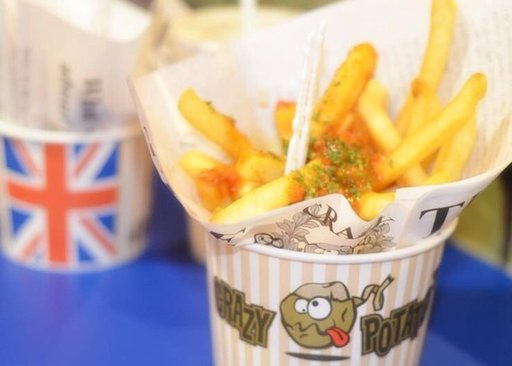

In [6]:
import random
from PIL import Image

# random.seed(42)

image_path_list = list(image_path.glob("*/*/*.jpg"))

random_image_path = random.choice(image_path_list)

image_class = random_image_path.parent.stem

img = Image.open(random_image_path)

print(f"Random image path:{random_image_path}")
print(f"Image class:{image_class}")
print(f"Image height:{img.height}")
print(f"Image width: {img.width}")
img

(np.float64(-0.5), np.float64(511.5), np.float64(365.5), np.float64(-0.5))

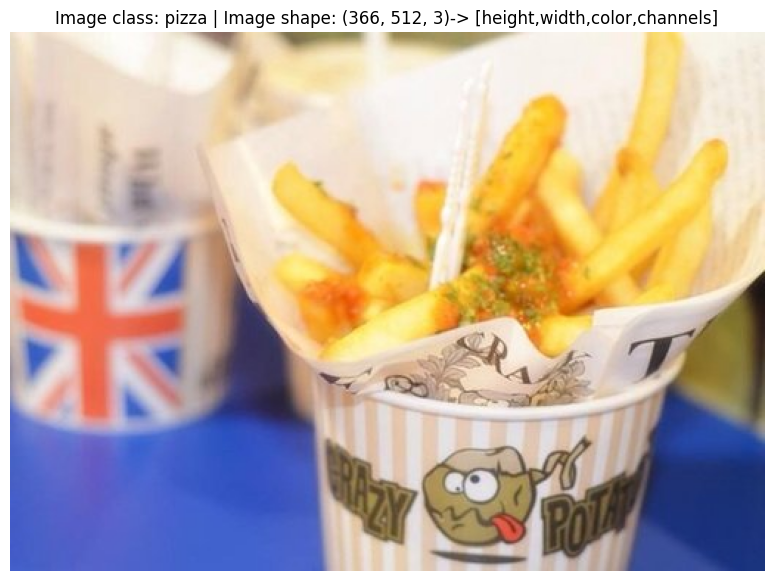

In [7]:
import numpy as np
import matplotlib.pyplot as plt

img_as_array = np.asarray(img)

plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape}-> [height,width,color,channels]")
plt.axis(False)

array([[[234, 221, 202],
        [235, 222, 203],
        [240, 225, 206],
        ...,
        [243, 241, 229],
        [243, 241, 229],
        [243, 241, 229]],

       [[234, 221, 202],
        [235, 222, 203],
        [240, 225, 206],
        ...,
        [243, 241, 229],
        [243, 241, 229],
        [243, 241, 229]],

       [[233, 221, 199],
        [234, 222, 200],
        [239, 224, 205],
        ...,
        [244, 242, 230],
        [243, 241, 229],
        [243, 241, 229]],

       ...,

       [[ 69,  96, 203],
        [ 68,  95, 202],
        [ 68,  95, 202],
        ...,
        [ 26,  52, 126],
        [ 26,  53, 124],
        [ 26,  53, 124]],

       [[ 68,  96, 203],
        [ 68,  96, 203],
        [ 68,  96, 203],
        ...,
        [ 26,  52, 126],
        [ 26,  53, 124],
        [ 26,  53, 124]],

       [[ 68,  96, 203],
        [ 68,  96, 203],
        [ 68,  96, 203],
        ...,
        [ 26,  52, 126],
        [ 26,  53, 124],
        [ 26,  53, 124]]], dtype=uint8)
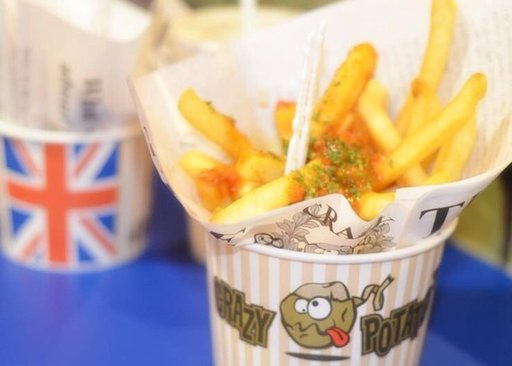

In [8]:
img_as_array

In [9]:
#3. Transforming data
import torch
from torch.utils.data import DataLoader
from torchvision import datasets,transforms

In [10]:
#Write transform for image
data_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
    ])

In [11]:
data_transform(img)

tensor([[[0.9490, 0.9686, 0.9255,  ..., 0.9686, 0.9608, 0.9569],
         [0.9294, 0.9608, 0.9216,  ..., 0.9647, 0.9608, 0.9529],
         [0.9216, 0.9490, 0.9216,  ..., 0.9529, 0.9529, 0.9490],
         ...,
         [0.2667, 0.2745, 0.2863,  ..., 0.1020, 0.1059, 0.1098],
         [0.2627, 0.2706, 0.2863,  ..., 0.0980, 0.1020, 0.1059],
         [0.2667, 0.2706, 0.2824,  ..., 0.1020, 0.0980, 0.1020]],

        [[0.8941, 0.9176, 0.8627,  ..., 0.9529, 0.9490, 0.9451],
         [0.8745, 0.9059, 0.8549,  ..., 0.9451, 0.9373, 0.9294],
         [0.8627, 0.8863, 0.8510,  ..., 0.9333, 0.9216, 0.9176],
         ...,
         [0.3608, 0.3725, 0.3765,  ..., 0.1961, 0.1961, 0.1961],
         [0.3647, 0.3686, 0.3765,  ..., 0.1961, 0.2000, 0.2039],
         [0.3725, 0.3765, 0.3765,  ..., 0.2000, 0.2000, 0.2039]],

        [[0.8157, 0.8431, 0.7922,  ..., 0.9098, 0.9020, 0.8980],
         [0.7804, 0.8078, 0.7922,  ..., 0.9020, 0.8941, 0.8824],
         [0.7765, 0.7882, 0.7961,  ..., 0.8902, 0.8745, 0.

In [12]:
def plot_transformed_images(image_paths: list,transform,n=3,seed=None):
  if seed:
    random.seed(seed)
  random_image_paths = random.sample(image_paths,k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(nrows=1,ncols=2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original\nSize: {f.size}")
      ax[0].axis(False)

      transformed_image = transform(f).permute(1,2,0)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
      ax[1].axis("off")

      fig.suptitle(f"Class: {image_path.parent.stem}",fontsize=16)

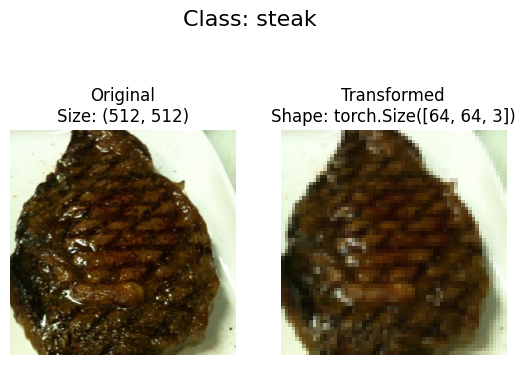

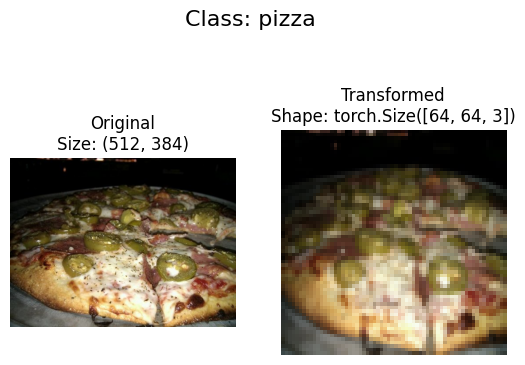

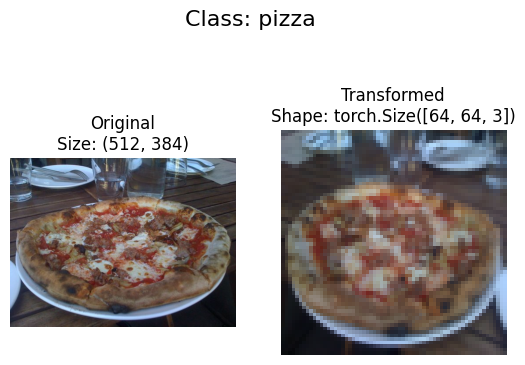

In [13]:
plot_transformed_images(image_path_list,
                        data_transform,3,42 )

In [14]:
#use ImageFolder to create dataset(s)
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,transform=data_transform,
                                  target_transform=None)
test_data = datasets.ImageFolder(root=test_dir,
                                 transform = data_transform)
train_data,test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [15]:
class_names = train_data.classes
class_dict = train_data.class_to_idx
class_names,class_dict

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [16]:
len(train_data),train_data.samples[0],len(test_data),test_data.samples[0]

(225,
 ('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0),
 75,
 ('data/pizza_steak_sushi/test/pizza/1152100.jpg', 0))

In [17]:
img,label = train_data[0][0],train_data[0][1]
print(f"Image tensor:\n {img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Image class: {class_names[label]}")
print(f"Label datatype: {type(label)}")

Image tensor:
 tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.0

Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Image permute shape: torch.Size([64, 64, 3]) -> [height, width, color_channels]


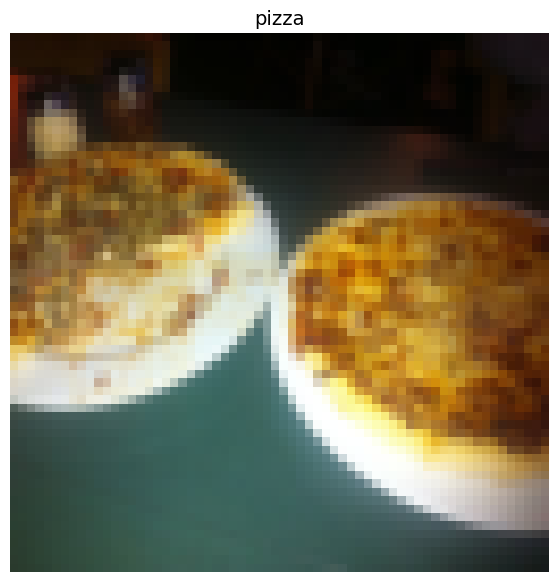

In [18]:
# Rearrange the order of dimensions
img_permute = img.permute(1, 2, 0)

# Print out different shapes (before and after permute)
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute shape: {img_permute.shape} -> [height, width, color_channels]")

# Plot the image
plt.figure(figsize=(10, 7))
plt.imshow(img.permute(1, 2, 0))
plt.axis("off")
plt.title(class_names[label], fontsize=14);